In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device :",device)

Using Device : cpu


In [40]:

df = pd.read_csv("D:\mca_aiml_lab\mca_env\Datasets\cleaned_weather.csv")

df.head()

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_15876\3843065481.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  df = pd.read_csv("D:\mca_aiml_lab\mca_env\Datasets\cleaned_weather.csv")


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81


In [41]:
df.shape

(52696, 21)

In [42]:
df["DateTime"] = pd.to_datetime(df["date"].astype(str),errors="coerce")



In [43]:
df = df.sort_values("DateTime").reset_index(drop=True)

df.head()

,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog,DateTime
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45,2020-01-01 00:10:00
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51,2020-01-01 00:20:00
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60,2020-01-01 00:30:00
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70,2020-01-01 00:40:00
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81,2020-01-01 00:50:00


In [44]:
numeric_df = df.iloc[:,1:-1]
numeric_df

,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,H2OC,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,5.49,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,5.45,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,5.43,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,5.37,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,5.42,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52691,978.32,2.28,277.16,-0.80,80.0,7.20,5.76,1.44,3.67,5.89,1234.61,0.73,1.40,180.6,0.0,0.0,0.0,0.0,0.0,13.40
52692,978.30,2.13,277.01,-0.43,83.1,7.12,5.92,1.20,3.77,6.05,1235.20,0.43,0.82,174.0,0.0,0.0,0.0,0.0,0.0,13.42
52693,978.26,1.99,276.88,-0.71,82.2,7.05,5.80,1.26,3.69,5.93,1235.82,0.38,0.76,248.9,0.0,0.0,0.0,0.0,0.0,13.45
52694,978.26,2.07,276.95,-0.77,81.4,7.09,5.77,1.32,3.68,5.90,1235.49,0.57,1.07,196.6,0.0,0.0,0.0,0.0,0.0,13.47


In [45]:
df.isnull().sum()

date        0
p           0
T           0
Tpot        0
Tdew        0
rh          0
VPmax       0
VPact       0
VPdef       0
sh          0
H2OC        0
rho         0
wv          0
max. wv     0
wd          0
rain        0
raining     0
SWDR        0
PAR         0
max. PAR    0
Tlog        0
DateTime    0
dtype: int64

In [46]:
numeric_df.isnull().sum()

p           0
T           0
Tpot        0
Tdew        0
rh          0
VPmax       0
VPact       0
VPdef       0
sh          0
H2OC        0
rho         0
wv          0
max. wv     0
wd          0
rain        0
raining     0
SWDR        0
PAR         0
max. PAR    0
Tlog        0
dtype: int64

In [47]:
numeric_df= numeric_df.interpolate(method="linear", limit_direction="both")
numeric_df= numeric_df.ffill().bfill()

In [78]:
# Convert df to numpy

features_names = numeric_df.columns.tolist()

num_features = df.shape[1]

print("Features Used :",features_names)
num_features

Features Used : ['p', 'T', 'Tpot', 'Tdew', 'rh', 'VPmax', 'VPact', 'VPdef', 'sh', 'H2OC', 'rho', 'wv', 'max. wv', 'wd', 'rain', 'raining', 'SWDR', 'PAR', 'max. PAR', 'Tlog']


22

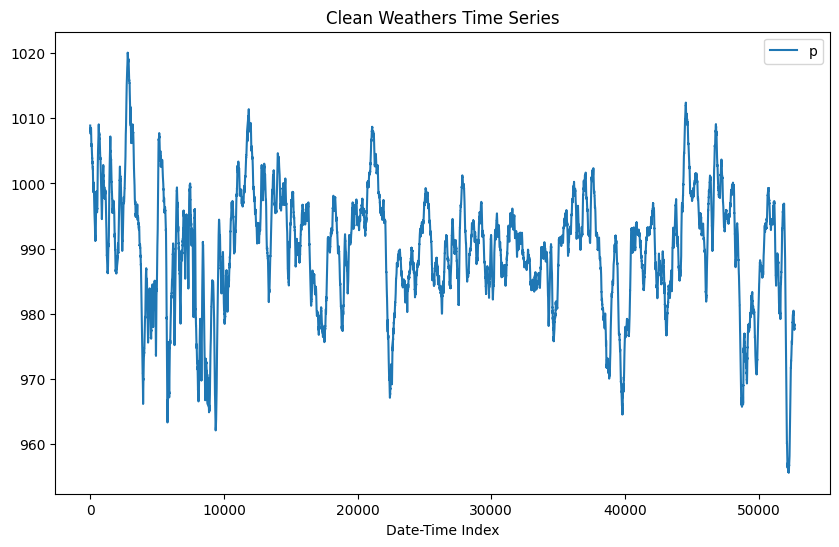

In [79]:
# visualize your time series

plt.figure(figsize=(10,6))
plt.plot(numeric_df.index, numeric_df[features_names[0]],label=features_names[0])
# Plot the first features as an example
plt.title('Clean Weathers Time Series')
plt.xlabel("Date-Time Index")
plt.legend()
plt.show()

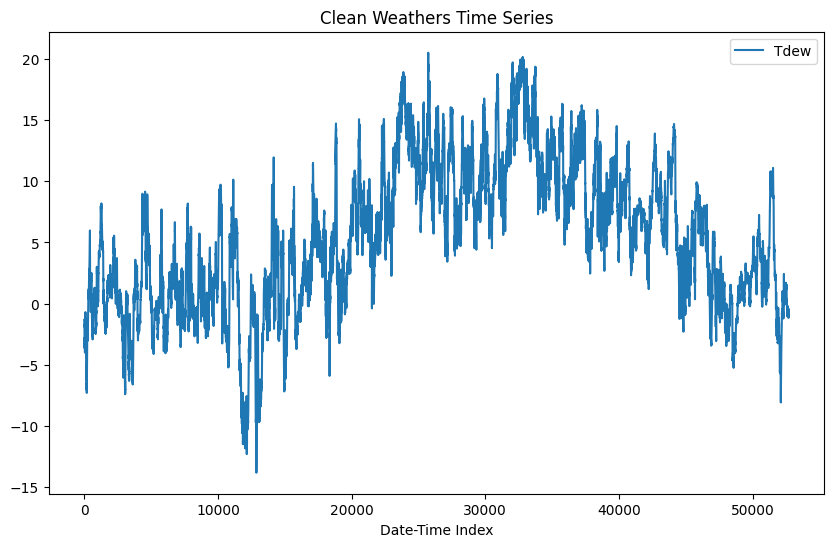

In [80]:
plt.figure(figsize=(10,6))
plt.plot(numeric_df.index, numeric_df[features_names[3]],label=features_names[3])
# Plot the first features as an example
plt.title('Clean Weathers Time Series')
plt.xlabel("Date-Time Index")
plt.legend()
plt.show()

In [81]:
# Convert df to numpy

data = numeric_df.values.astype(np.float32)
print("Data Shape",data.shape)
data

Data Shape (52696, 20)


array([[1.00889e+03, 7.10000e-01, 2.73180e+02, ..., 0.00000e+00,
        0.00000e+00, 1.14500e+01],
       [1.00876e+03, 7.50000e-01, 2.73220e+02, ..., 0.00000e+00,
        0.00000e+00, 1.15100e+01],
       [1.00866e+03, 7.30000e-01, 2.73210e+02, ..., 0.00000e+00,
        0.00000e+00, 1.16000e+01],
       ...,
       [9.78260e+02, 1.99000e+00, 2.76880e+02, ..., 0.00000e+00,
        0.00000e+00, 1.34500e+01],
       [9.78260e+02, 2.07000e+00, 2.76950e+02, ..., 0.00000e+00,
        0.00000e+00, 1.34700e+01],
       [9.78240e+02, 2.01000e+00, 2.76890e+02, ..., 0.00000e+00,
        0.00000e+00, 1.34800e+01]], shape=(52696, 20), dtype=float32)

In [82]:

INPUT_STEPS = 10
OUTPUT_STEPS = 5
TRAIN_RATIO = 0.8
BATCH_SIZE = 4

In [72]:
# Train/Test SPLIT

# Train test split: 80:20
split_idx= int(TRAIN_RATIO*len(data))
train_data1= data[:split_idx]
test_data= data[split_idx:]

val_split_idx= int(len(train_data1)*TRAIN_RATIO)
train_data= train_data1[:val_split_idx]
val_data= train_data1[val_split_idx:]
train_data.shape, test_data.shape, val_data.shape





((33724, 20), (10540, 20), (8432, 20))

In [73]:
from sklearn.preprocessing import normalize

train_data_norm = normalize(train_data, norm='l2', axis=0)

test_data_norm = normalize(test_data, norm='l2', axis=0)
val_data_norm = normalize(val_data, norm='l2', axis=0)

In [74]:
import numpy as np

def create_sequences(data_array, input_steps=10, output_steps=5, overlap=1):
  X, y=[], []
  total_len= len(data_array)
  stride= input_steps-overlap
  if stride<=0:
    raise ValueError("overlap must be smaller than input_steps")

  for i in range(0, total_len-input_steps-output_steps + 1, stride):
    X.append(data_array[i:i+input_steps])
    y.append(data_array[i+input_steps:i + input_steps + output_steps])

  return np.array(X, dtype= np.float32), np.array(y, dtype=np.float32)

In [75]:
X_train, y_train= create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_test, y_test= create_sequences(test_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_val, y_val= create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)


X_train: (16855, 10, 20) y_train: (16855, 5, 20)
X_test: (5263, 10, 20) y_test: (5263, 5, 20)
X_val: (4209, 10, 20) y_val: (4209, 5, 20)


In [76]:
from torch.utils.data import Dataset
class TimeSeriesDataset(Dataset):
  def __init__(self, X, y) -> None:
    self.X= torch.tensor(X, dtype=torch.float32)
    self.y= torch.tensor(y, dtype= torch.float32)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

#### Defining Tensor dataset and DataLoader

In [77]:
train_dataset= TimeSeriesDataset(X_train, y_train)
test_dataset= TimeSeriesDataset(X_test, y_test)
val_dataset= TimeSeriesDataset(X_val, y_val)

train_loader= DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader= DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader= DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# EACH data point will be arranaged in shape (batch, seq_len, features)


#### Define Model

In [83]:
# Define model
class LSTMForecaster(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.lstm= nn.LSTM(len(features_names), hidden_size=10, batch_first=True)
    self.fc= nn.Linear(10, 5*len(features_names))

  def forward(self, x):
    out, _=self.lstm(x)
    out= self.fc(out[:,-1,:])
    return out.view(-1,5, len(features_names))



In [84]:
# Instantiating model with a schedular

model= LSTMForecaster().to(device)

lr= 0.001
optimizer= torch.optim.Adam(model.parameters(), lr=lr)
criterion= nn.MSELoss()

scheduler= torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, patience=10)

### Method for Training 1 epoch

In [65]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

#### Method for evaluation

In [66]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

### One Simple Training

In [85]:
EPOCHS = 10
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch [1/10] | Train Loss: 0.000317 | Val Loss: 0.000053
Epoch [2/10] | Train Loss: 0.000011 | Val Loss: 0.000044
Epoch [3/10] | Train Loss: 0.000008 | Val Loss: 0.000034
Epoch [4/10] | Train Loss: 0.000007 | Val Loss: 0.000031
Epoch [5/10] | Train Loss: 0.000006 | Val Loss: 0.000027
Epoch [6/10] | Train Loss: 0.000005 | Val Loss: 0.000026
Epoch [7/10] | Train Loss: 0.000005 | Val Loss: 0.000025
Epoch [8/10] | Train Loss: 0.000005 | Val Loss: 0.000024
Epoch [9/10] | Train Loss: 0.000005 | Val Loss: 0.000023
Epoch [10/10] | Train Loss: 0.000005 | Val Loss: 0.000024


#### Training with Early Stopping 

In [ ]:
#Training with early stopping based on validation loss

EPOCHS = 50
early_stop_patience = 5
train_losses = []
val_losses = [] 
best_val_loss = float('inf')
epochs_no_improve = 0



for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Save the best model
        torch.save(model.state_dict(), "best_model.pt")  # Save the best model
    else:
        epochs_no_improve += 1

    # Early stopping condition
    if epochs_no_improve >= early_stop_patience:
        print("Early stopping triggered! at epoch:", epoch+1)
        break   

Epoch [1/50] | Train Loss: 0.000005 | Val Loss: 0.000023
Epoch [2/50] | Train Loss: 0.000005 | Val Loss: 0.000023
Epoch [3/50] | Train Loss: 0.000005 | Val Loss: 0.000024
Epoch [4/50] | Train Loss: 0.000005 | Val Loss: 0.000024
Epoch [5/50] | Train Loss: 0.000005 | Val Loss: 0.000023
Epoch [6/50] | Train Loss: 0.000005 | Val Loss: 0.000024
Early stopping triggered! at epoch: 6
